# Getting Started with QMCPy

This notebook gives a hands‑on tour of the QMCPy library, which is desined to support __low discrepancy (LD)__ sequences and __quasi-Monte Carlo (qMC)__ methods:

<ol start="-1">
  <li>Initialization and importing <code>qmcpy</code> as <code>qp</code></li>
  <li>Why not grids?</li>
  <li>The <code>DiscreteDistributions</code> class and low discrepancy generators on $\cu[0,1]^d$</li>
  <li>The <code>TrueMeasure</code> class for mimicking distributions that are not standard uniform</li>
  <li>Designing your <code>Integrand</code> for use with Monte Carlo </li>
  <li>Adaptive  <code>StoppingCriterion</code> class for determining when to stop the simulation based on the desired error tolerance</li>
  <li>Examples of option pricing, control variates, and importance sampling</li>
</ol>

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\reals}{\mathbb{R}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\hmu}{\widehat{\mu}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/QMCPy_Introduction.ipynb?flush_cache=true)

In [1]:
# Colab-only setup
if "google.colab" in str(get_ipython()):
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop

### -1. Import needed packages and initialize some parameters

In [32]:
# ----- Standard packages -----
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp
import scipy as sp
import scipy.stats as stats
from IPython.display import display, Markdown

if not hasattr(np, "math"):
    np.math = math

# ----- Import classlib: rely on env, but verify path -----
import classlib as cl
print("classlib path:", cl.__file__)

#these generators are not in qmcpy yet, but in out class library 
qp.Kronecker = cl.generators.Kronecker
qp.TensorProductGrid = cl.generators.TensorProductGrid

# ----- Plotting / Style -----
%matplotlib inline

cl.nbviz.init(use_tex=True)
colors, TINY = cl.nbviz.TOL_BRIGHT, cl.nbviz.TINY
cl.nbviz.configure(figpath="QMCPy_Intro_figures", savefigs=True)

print("QMCPy version:", qp.__version__)
display(Markdown("All classes from `qmcpy` are accessed as `qp.classname`"))

classlib path: /Users/fredjhickernell/SoftwareRepositories/HickernellClassLib/classlib/__init__.py


QMCPy version: 2.0


All classes from `qmcpy` are accessed as `qp.classname`

## 0. Why not grids?
We often can write our problem as
$$
\mu = \int_{[0,1]^d} f(\vx) \dif \vx =?
$$
and we approximate $\mu$ by a sample mean,
$$
\hmu = \frac 1n \sum_{i=0}^{n-1} f(\vx_i)
$$

We know how to place points evenly in an interval, i.e., $d=1$.  E.g., the points 
$$
x_i = i/n, \quad i=0, \ldots, n-1
$$ 
are evenly spaced. 

However, when we want to work in dimension, $d$, greater than one, we have a _dilemma_.  Tensor product grids do not fill space well as we can see from the plots below.  For a $4$-dimensional grid of $n=256$ points we only have __four__ distinct values for each coordinate.

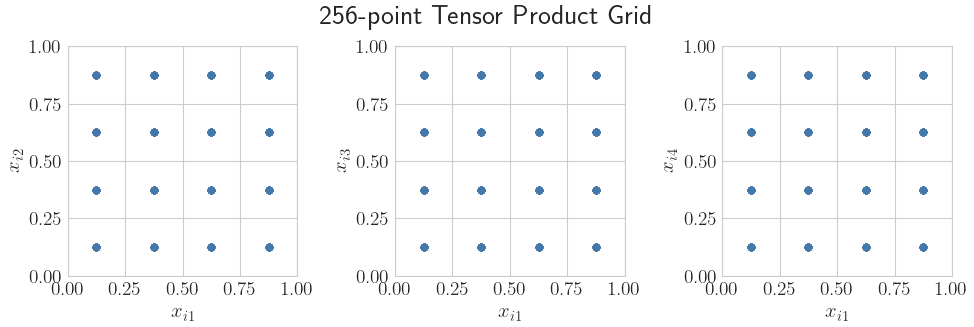

In [3]:
levels_per=4  #number of distinct values per coordinate
d=4  #dimension
grid_levels = [levels_per]*d  #list of levels per coordinate
grid = qp.TensorProductGrid(grid_levels)  #generate grid
fig, ax = qp.plot_proj(  #helper function to plot sample nodes
    grid,
    n=grid.n_total,
    d_horizontal=[1],
    d_vertical=[2,3,4],
    marker_size=20,
    figfac=10,
    where_title=0.545,
    fig_title=f"{grid.n_total}-point Tensor Product Grid",
)

We only see $16$ points in each two-dimensional projection.

## 1. Discrete distributions and low‑discrepancy (LD) points

A `DiscreteDistribution` object in QMCPy generates an $n\times d$ array of points in $[0,1)^d$:

- Rows = independent *samples*.
- Columns = *coordinates* (dimensions).

For IID sampling the rows are independent uniforms and there is no preferred ordering.
For LD sequences
- digital (Sobol' is the most well-known)
- lattices,
- Kronecker, and
- Halton,
the points are highly structured so that **every low‑dimensional projection looks well‑filled**.

### 1.1 Constructing and calling LD samplers
We first construct a dictionary of samplers for later use and then show the output from one.  This same syntax is used on the the `DiscreteDistribution` objects

In [4]:
x_sobol = qp.Sobol(dimension=5,randomize=False)(n=16)
print("This array of Sobol' points has shape", x_sobol.shape, "and the first several points are\n", x_sobol[:5])

This array of Sobol' points has shape (16, 5) and the first several points are
 [[0.    0.    0.    0.    0.   ]
 [0.5   0.5   0.5   0.5   0.5  ]
 [0.25  0.75  0.75  0.75  0.25 ]
 [0.75  0.25  0.25  0.25  0.75 ]
 [0.125 0.625 0.375 0.125 0.125]]


/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)


You may see a warning about the first point being the origin.  If this point is later transformed by the inverse Gaussian distribution then it becomes $-\boldsymbol{\infty}$, which can cause numerical problems.  We talk about how to avoid those problems later.

### 1.2 Visualizing projections with `plot_proj`

QMCPy includes a helper `plot_proj` that plots 2D projections of a `DiscreteDistribution`.
This is a quick way to *see* the difference between IID points and LD points.

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)
/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/lattice/lattice.py:248: ParameterWarning: Without randomization, the first lattice point is the origin
  warnings.warn("Without randomization, the first lattice point is the origin",ParameterWarning)
/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/halton.py:263: UserWarning: Without randomization, the first Halton point is the origin
  warnings.warn("Without randomization, the first Halton point is the origin")


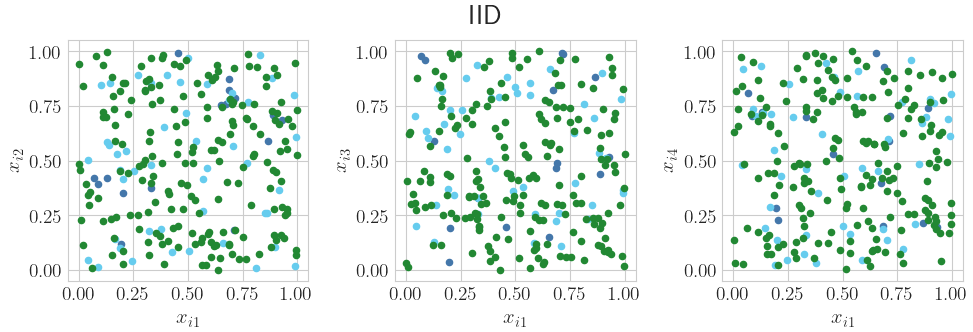

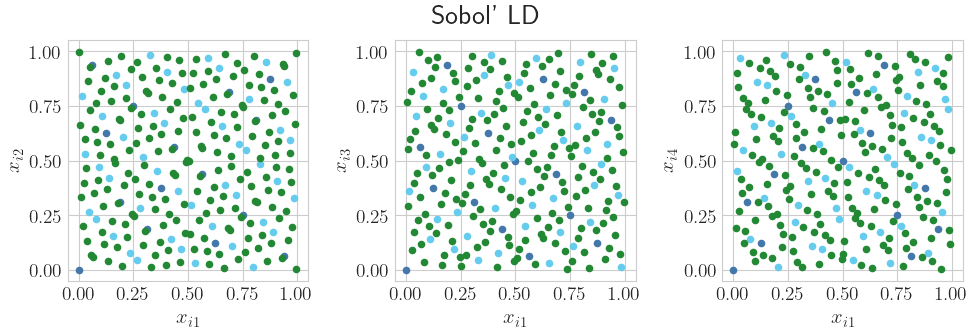

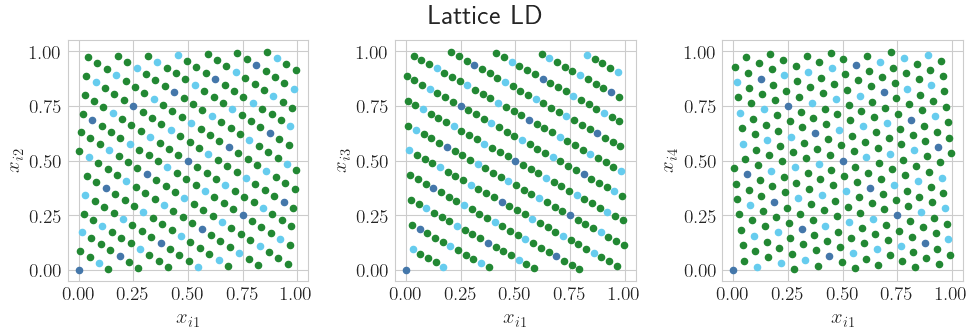

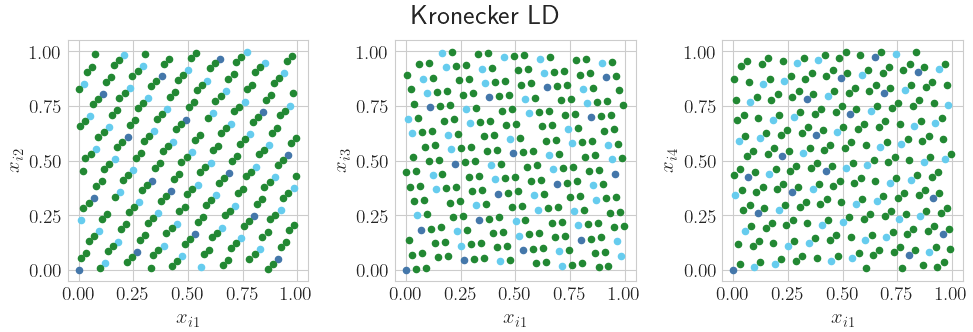

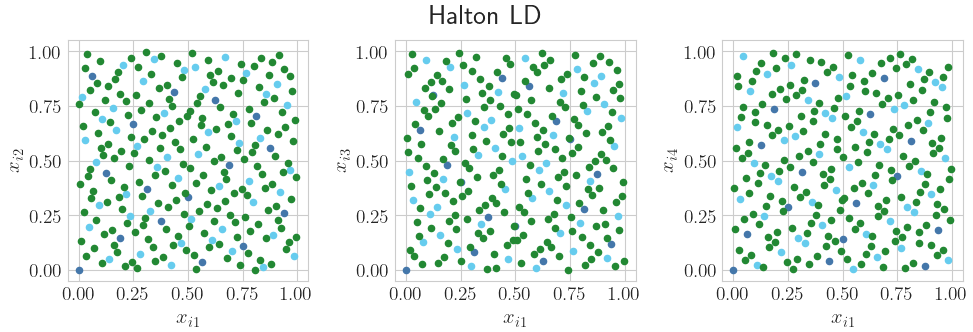

In [5]:
samplers = {  #these are samplers that we will use for our examples later
    "iid":       lambda d, random=True: {"gen": qp.IIDStdUniform(d), "label": "IID"},
    "sobol":     lambda d, random=True: {"gen": qp.Sobol(d,randomize=random),      "label": "Sobol' LD"},
    "lattice":   lambda d, random=True: {"gen": qp.Lattice(d,randomize=random),    "label": "Lattice LD"},
    "kronecker": lambda d, random=True: {"gen": qp.Kronecker(d, randomize=random), "label": "Kronecker LD"},
    "halton":    lambda d, random=True: {"gen": qp.Halton(d,randomize=random),     "label": "Halton LD"}
}

d=4
the_samplers = {name: key(d, False) for name, key in samplers.items()} #initialize samplers with d and no randomization
n_plot = [16, 64, 256]  #list of sample sizes to plot
d_horiz = 1  #coordinate(s) for the horizontal axis or axes
d_vert = [2, 3, 4]  #coordinates for the vertical axis or axes

for key, s in the_samplers.items():
    fig, ax = qp.plot_proj(
        s["gen"],
        n=n_plot,
        d_horizontal=d_horiz,
        d_vertical=d_vert,
        axis_pad=0.05,
        marker_size=20,
        figfac=10,  #how big do you want your figures
        fig_title=s["label"],
        where_title=0.545,  #for some reason, this has to be fiddled with to look nice
    )
    cl.nbviz.savefig(s["label"])


Points numbered 0 to 15 are <span style="color:#4477AA; font-size:200%; position:relative; top:3px;">•</span>. Points numbered 16 to 63 are <span style="color:#66CCEE; font-size:200%; position:relative; top:3px;">•</span>.  Points numbered 64 to 255 are <span style="color:#228833; font-size:200%; position:relative; top:3px;">•</span>.  As the sample size increases the points fill the unit cube.  

- In contrast to the four-dimensional grid, these LD points have great two-dimensional projections.
- IID points are better than grids in four dimensions, but worse than LD.

### 1.3 Get the rows and columns right
Note that all `DiscreteDistribution` generators return arrays of shape `(n, dimension)`.

For LD sequences like Sobol' and lattice, Halton, and Kronecker, *which column is which coordinate matters*:

- Column 0 always holds the first coordinate $x_{i1}$ of every sample, $\vx_i$.
- Column 1 always holds the second coordinate $x_{i2}$, of every sample, $\vx_i$, etc.

If we plot the transpose of an IID array it looks similar, but the transpose of an LD array does not look so nice.

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)


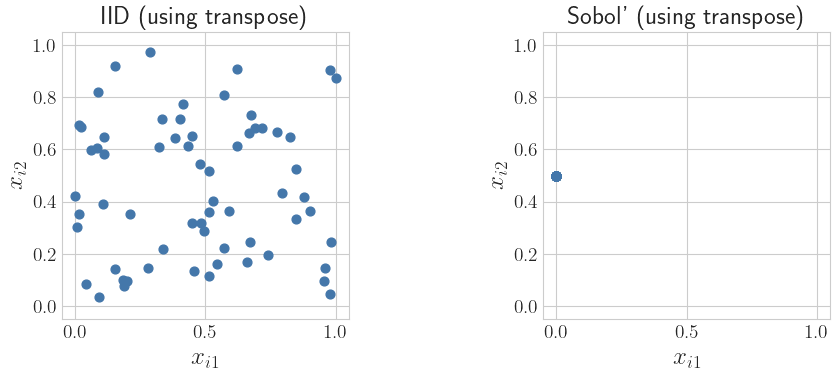

In [6]:
d = 64
n = 64
# Correctly shaped samples: shape (n, d)
x_iid   = qp.IIDStdUniform(d)(n)
x_sobol = qp.Sobol(d,randomize=False)(n)

# Now "confuse" dimensions: transpose so shape (d, n)
x_iid_T   = x_iid.T
x_sobol_T = x_sobol.T

# Treat rows as points and columns as coordinates:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(x_iid_T[:, 0], x_iid_T[:, 1], s=40)
axes[0].set_title("IID (using transpose)")
axes[1].set_title("Sobol' (using transpose)")
axes[1].scatter(x_sobol_T[:, 0], x_sobol_T[:, 1], s=40)
for ax in axes:
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("$x_{i1}$")
    ax.set_ylabel("$x_{i2}$")
plt.tight_layout()

Since the original Sobol' points are $\vx_0 = (0, \ldots, 0)$ and $\vx_1 = (0.5, \ldots, 0.5)$, the $64$ points using the transpose are all the same, i.e., $64$ copies of $(0,0.5)$.

The LD construction is designed so that

- the _low-dimensional_ projections of _lower-numbered_ coordinates are very evenly spread,
- while higher-dimensional projections and/or projections of higher numbered coordinates may be less evenly spread.

Thus, when possible, it is better to construct your function, $f$, to depend more on lower-dimensional projections and more on lower-numbered coordinates.

By contrast, for IID points the evenness is not as good as low discepancy points, their performance does not depend on which coordinate you are looking at.  Here we show some larger dimensions for IID and Sobol'

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)


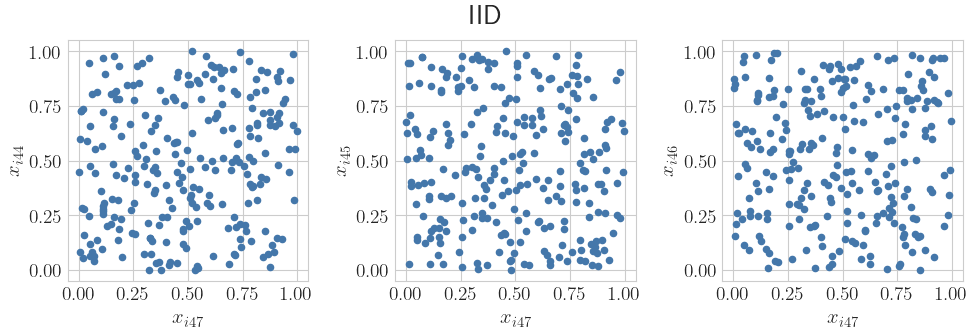

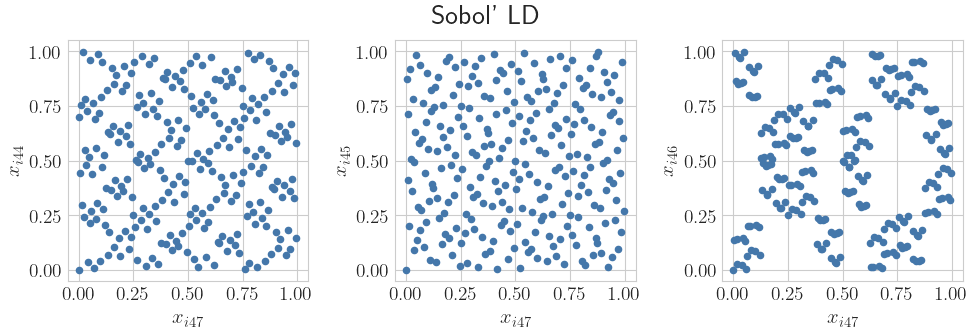

In [7]:
d=47
the_samplers = {name: key(d, False) for name, key in samplers.items()} #initialize samplers with d and no randomization
n_plot = [256]  #list of sample sizes to plot
d_horiz = 47  #coordinate(s) for the horizontal axis or axes
d_vert = [44, 45, 46]  #coordinates for the vertical axis or axes

keys_to_plot = ["iid", "sobol"]
for key in keys_to_plot:
    s = the_samplers[key]
    fig, ax = qp.plot_proj(
        s["gen"],
        n=n_plot,
        d_horizontal=d_horiz,
        d_vertical=d_vert,
        axis_pad=0.05,
        marker_size=20,
        figfac=10,  #how big do you want your figures
        fig_title=s["label"],
        where_title=0.545,  #for some reason, this has to be fiddled with to look nice
    )
    cl.nbviz.savefig(s["label"])

Notice that the IID figures look about the same as above, but the Sobol' sampling does not look quite as good for some two-dimensional projections.

### 1.4 Randomize to get points of the boundary

All of these LD samples can be randomized 
* To make
$ \displaystyle
\hmu = \frac 1n \sum_{i=0}^{n-1} f(\vx_i)
$
an unbiased estimator for $\mu$, and
* To ensure that nodes do not lie on the boundary of the unit cube.

These randomizations take the form of
* Random shifts modulo one for lattice, Kronecker, and Halton,
* Random digital shifts plus linear matrix or nested uniform scrambling of the digits of digital nets and Halton.
These randomizations preserve the LD structure.

We encourage that the `randomization` logical argument be left as its default, which is True. Here are some pictures of randomized LD sequences.

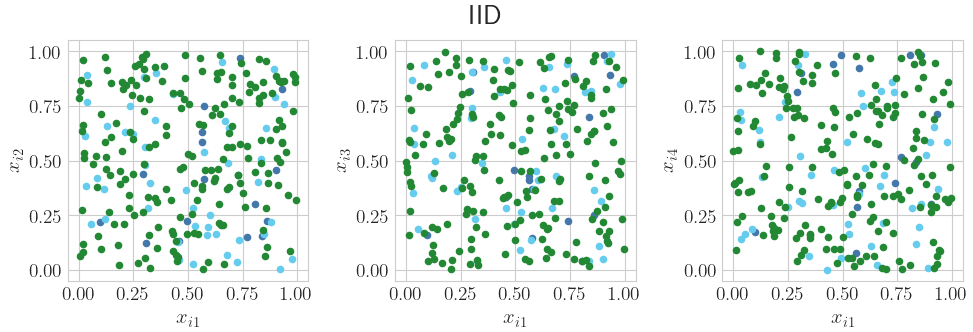

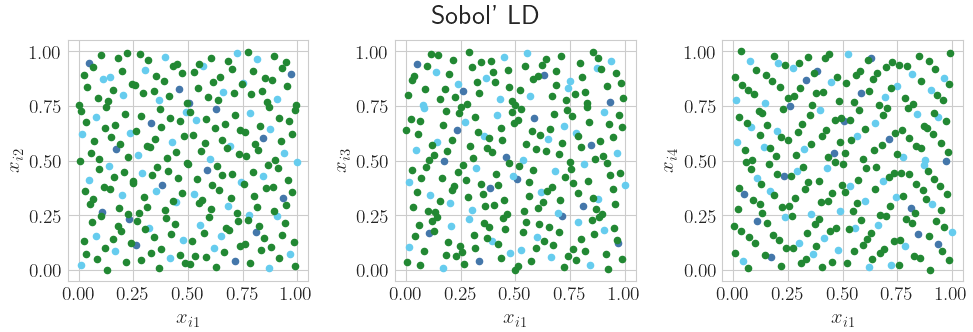

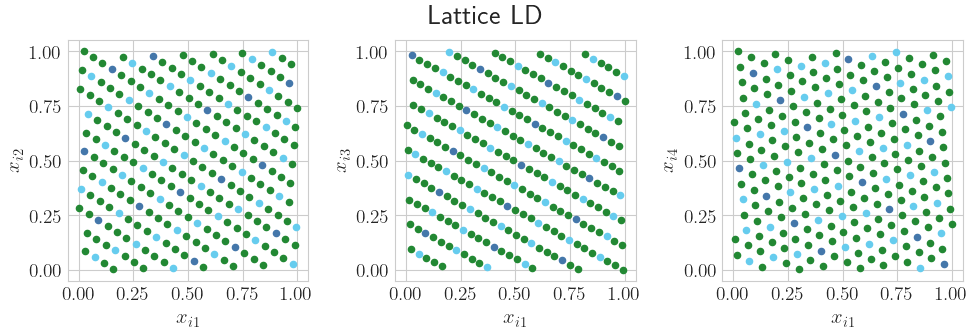

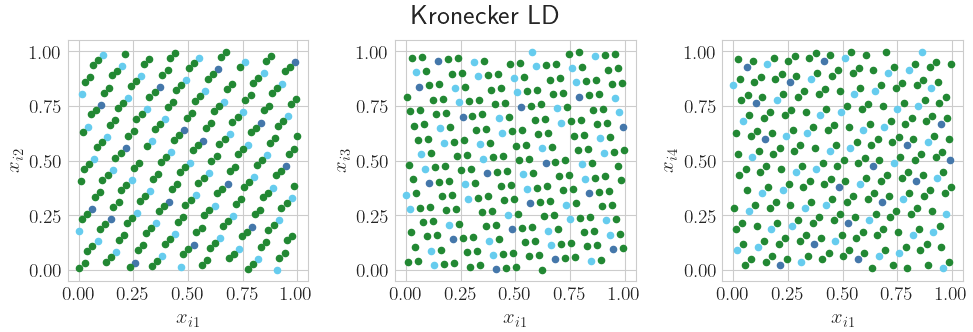

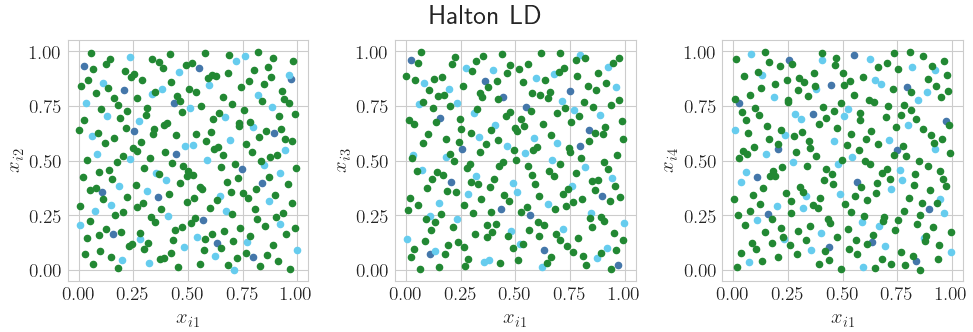

In [8]:
d=4
the_samplers = {name: key(d) for name, key in samplers.items()} #initialize samplers with d and randomization
n_plot = [16, 64, 256]  #list of sample sizes to plot
d_horiz = 1  #coordinate(s) for the horizontal axis or axes
d_vert = [2, 3, 4]  #coordinates for the vertical axis or axes

for key, s in the_samplers.items():
    fig, ax = qp.plot_proj(
        s["gen"],
        n=n_plot,
        d_horizontal=d_horiz,
        d_vertical=d_vert,
        axis_pad=0.05,
        marker_size=20,
        figfac=10,  #how big do you want your figures
        fig_title=s["label"],
        where_title=0.545,  #for some reason, this has to be fiddled with to look nice
    )

## 2. From uniform to other distributions: `TrueMeasure`

A `DiscreteDistribution` generates points in $[0,1)^d$ that *mimic* a base distribution (usually standard uniform).
A `TrueMeasure` wraps a discrete distribution and transforms its points so that they mimic another distribution, such as a Gaussian or Exponential.

Conceptually:

1. Start with LD points $\boldsymbol{u}_i \in [0,1)^d$
2. Apply a transformation $\boldsymbol{\Psi}: [0,1)^d \to \mathcal{X}$, where $\mathcal{X}$ is the sample space of the desired distribution (e.g., inverse Gaussian CDF) to get $\boldsymbol{x}_i = \boldsymbol{\Psi}(\boldsymbol{u}_i)$
   - This may be done coordinate-wise or
   - In the case of multivariate Gaussian, as coordinate-wise and then a linear transformation
4. Use the transformed points ${\boldsymbol{x}_i}$ to approximate expectations with respect to the new distribution

### Multivariate Gaussian

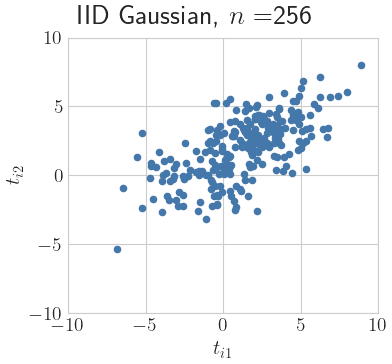

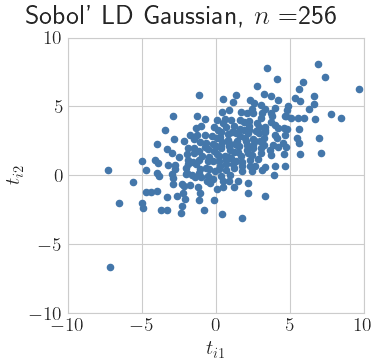

In [26]:
d = 2
the_samplers = {name: key(d) for name, key in samplers.items()} #initialize samplers with d and randomization
n = 2**8
keys_to_plot = ["iid", "sobol"]
for key in keys_to_plot:
    s = the_samplers[key] 
    # Wrap the base sampler in a Gaussian transformation
    gaussian = qp.Gaussian(s["gen"], mean=[1, 2], covariance=[[9, 4],[4, 5]])

    fig, ax = qp.plot_proj(
        gaussian,
        n=n,
        d_horizontal=1,
        d_vertical=2,
        axis_pad=0.05,
        marker_size=20,
        figfac=4,  # how big do you want your figures
        fig_title=f"{s['label']} Gaussian, $n=${n}",
        where_title=0.93,
    )
    ax[0,0].set_xlim([-10,10])
    ax[0,0].set_ylim([-10,10])

### SciPy Distributions
We can also harness the distributions in `scipy`, which allows different distributions for each marginal

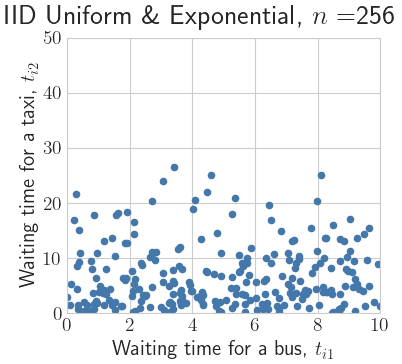

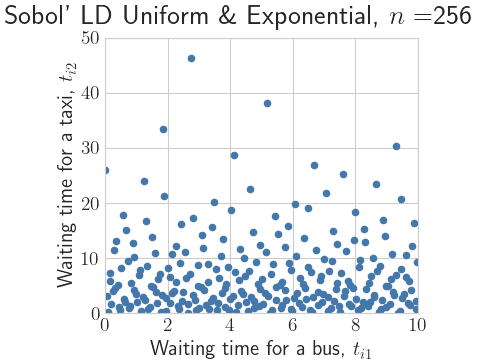

In [40]:
for key in keys_to_plot:
    s = the_samplers[key] 
    # Wrap the base sampler in a disribution whose first coordinate is uniform and second is exponential
    gaussian = qp.SciPyWrapper(s["gen"], 
                               scipy_distribs = [ 
                                   stats.uniform(loc=0,scale=10),
                                   stats.expon(scale=7)])

    fig, ax = qp.plot_proj(
        gaussian,
        n=n,
        d_horizontal=1,
        d_vertical=2,
        axis_pad=0.05,
        marker_size=20,
        figfac=4,  # how big do you want your figures
        fig_title=f"{s['label']} Uniform \& Exponential, $n=${n}",
        where_title=0.93,
    )
    ax[0,0].set_xlim([0,10])
    ax[0,0].set_ylim([0,50])
    ax[0,0].set_xlabel(r"Waiting time for a bus, $t_{i1}$")
    ax[0,0].set_ylabel(r"Waiting time for a taxi, $t_{i2}$")

In [9]:
raise SystemExit("Stopping here — notebook not finished past this point.")

SystemExit: Stopping here — notebook not finished past this point.

/opt/anaconda3/envs/qmcpy/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 3. Integrands: `CustomFun` and built‑in classes

An `Integrand` represents the function whose expectation we want to estimate.

- `qp.CustomFun(true_measure, custom_fun=...)` lets you plug in any Python function.
- Built‑in integrands (e.g. `Keister`, `AsianOption`, `EuropeanOption`, etc.) wrap common test problems and finance models.

We'll start with a classic example: the Keister integral.

In [ ]:
from numpy.linalg import norm

# Keister test integrand
def keister(x):
    """x: n x d array, returns length-n vector."""
    d = x.shape[1]
    r = norm(x, axis=1)
    return np.pi**(d/2) * np.cos(r)

d = 5
sobol = qp.Sobol(dimension=d)

gaussian = qp.Gaussian(sobol, mean=0.0, covariance=0.5)
keister_integrand = qp.CustomFun(gaussian, custom_fun=keister)

keister_integrand

## 4. Adaptive stopping criteria

QMCPy separates *what* to integrate (the `Integrand`) from *how long* to integrate (the `StoppingCriterion`).

A stopping criterion object

- takes an integrand and user‑specified tolerances (absolute and/or relative),
- repeatedly requests more samples from the underlying distribution,
- stops once the estimated error is within tolerance.

Some commonly used classes are:

- `qp.CubMCG` – IID Monte Carlo with guaranteed error bounds.
- `qp.CubQMCSobolG` – QMC with Sobol' points.
- `qp.CubQMCLatticeG` – QMC with lattice points.
- `qp.CubQMCCLT` – Central Limit Theorem based error estimation.

All share the same basic interface:

```python
stopper = qp.CubQMCSobolG(integrand, abs_tol=1e-3, rel_tol=0)
solution, data = stopper.integrate()
```

In [ ]:
d = 5
abs_tol = 1e-3

# QMC: Sobol' + Gaussian + Keister
sobol = qp.Sobol(dimension=d)
keister_qmc = qp.CustomFun(qp.Gaussian(sobol, mean=0.0, covariance=0.5), custom_fun=keister)
qmc_stop = qp.CubQMCSobolG(keister_qmc, abs_tol=abs_tol, rel_tol=0)
qmc_solution, qmc_data = qmc_stop.integrate()

# MC: IID + Gaussian + Keister
iid = qp.IIDStdUniform(dimension=d)
keister_mc = qp.CustomFun(qp.Gaussian(iid, mean=0.0, covariance=0.5), custom_fun=keister)
mc_stop = qp.CubMCG(keister_mc, abs_tol=abs_tol, rel_tol=0)
mc_solution, mc_data = mc_stop.integrate()

print("Target abs tolerance:", abs_tol)
print("QMC (Sobol') solution = {:.6f}, n = {:d}".format(qmc_solution, int(qmc_data.n_total)))
print("MC  (IID)   solution = {:.6f}, n = {:d}".format(mc_solution, int(mc_data.n_total)))

Even for this small example, you should see that the Sobol' QMC method typically needs **far fewer samples** than IID Monte Carlo to hit the same error tolerance.

## 5. Example: Asian option pricing

QMCPy includes several finance integrands. Here we use an `AsianOption` to price an arithmetic‑mean call option on a geometric Brownian motion.

We'll compare:

- IID Monte Carlo (`CubMCG` with `IIDStdUniform`),
- Sobol' QMC (`CubQMCSobolG` with `Sobol`).


In [ ]:
dimension = 12  # monthly monitoring over 1 year

# IID Monte Carlo sampler and integrand
iid_points = qp.IIDStdUniform(dimension=dimension)
Asian_IID = qp.AsianOption(
    iid_points,
    volatility=0.50,
    start_price=120.0,
    strike_price=130.0,
    interest_rate=0.02,
    t_final=1.0,
    call_put='call',
    mean_type='arithmetic',
)

# Sobol' QMC sampler and integrand
sobol_points = qp.Sobol(dimension=dimension)
Asian_Sobol = qp.AsianOption(
    sobol_points,
    volatility=0.50,
    start_price=120.0,
    strike_price=130.0,
    interest_rate=0.02,
    t_final=1.0,
    call_put='call',
    mean_type='arithmetic',
)

abs_tol = 0.01

mc_stop = qp.CubMCG(Asian_IID, abs_tol=abs_tol, rel_tol=0)
qmc_stop = qp.CubQMCSobolG(Asian_Sobol, abs_tol=abs_tol, rel_tol=0)

price_mc, data_mc = mc_stop.integrate()
price_qmc, data_qmc = qmc_stop.integrate()

print("Asian call option (arithmetic mean)")
print("Target abs_tol =", abs_tol)
print("MC  price = {:.4f}, n = {:d}".format(price_mc, int(data_mc.n_total)))
print("QMC price = {:.4f}, n = {:d}".format(price_qmc, int(data_qmc.n_total)))

## 6. Variance reduction: control variates and importance sampling

Two standard variance‑reduction tricks in (Q)MC are:

- **Control variates:** subtract a function with known mean.
- **Importance sampling:** change the sampling distribution to focus on the most important regions.

QMCPy can help with both by providing flexible sampling (`DiscreteDistribution` and `TrueMeasure`) and by letting you post‑process samples in Python.

### 6.1 A simple control variate example

Suppose we want to estimate

$$\mu = \mathbb{E}[f(X)], \quad X \sim U[0,1]^d.$$

Take a function $g$ with known mean $\mathbb{E}[g(X)]$, and define

$$\tilde f(X) = f(X) - c\,(g(X) - \mathbb{E}[g(X)]).$$

Then $\mathbb{E}[\tilde f(X)] = \mu$ for any constant $c$, but for a good choice of $c$ the variance can be much smaller.

Here we'll use QMCPy just to generate nodes, and do the control‑variate algebra in NumPy.

In [ ]:
dimension = 4
n = 2**12

sobol = qp.Sobol(dimension=dimension)

def f(x):
    """Target integrand: mildly nonlinear."""
    return np.exp(x.sum(axis=1))

# Control variate: linear function with known mean
# g(x) = sum_j x_j, so E[g] = d/2 on [0,1]^d
def g(x):
    return x.sum(axis=1)

x = sobol.gen_samples(n)
fx = f(x)
gx = g(x)

mu_g = dimension / 2.0

# Optimal c (in least-squares sense) estimated from the sample
c_hat = np.cov(fx, gx, bias=True)[0, 1] / np.var(gx)

mc_plain = fx.mean()
mc_cv = (fx - c_hat * (gx - mu_g)).mean()

print("Plain QMC estimate       = {:.6f}".format(mc_plain))
print("Control variate estimate  = {:.6f}".format(mc_cv))

### 6.2 Importance sampling with QMCPy

For importance sampling, we want

$$\mu = \mathbb{E}_{X\sim p}[f(X)] = \mathbb{E}_{Y\sim q}\Bigl[f(Y)\,\frac{p(Y)}{q(Y)}\Bigr],$$

so we:

1. choose an easier proposal distribution $q$, 
2. sample $Y_i$ from $q$,
3. weight each sample by $w_i = p(Y_i)/q(Y_i)$.

QMCPy's `TrueMeasure` class makes it easy to swap $p$ and $q$ by composing different transforms.
Below is a very simple Gaussian example (done with IID points for clarity).

In [ ]:
n = 10_000

# Target: X ~ N(0, 1), proposal: Y ~ N(1, 1)

# IID uniforms for target and proposal (kept separate for clarity)
base_target = qp.IIDStdUniform(dimension=1)
base_proposal = qp.IIDStdUniform(dimension=1)

gauss_target = qp.Gaussian(base_target, mean=0.0, covariance=1.0)
gauss_proposal = qp.Gaussian(base_proposal, mean=1.0, covariance=1.0)

X = gauss_target.gen_samples(n)[:, 0]   # standard MC samples
Y = gauss_proposal.gen_samples(n)[:, 0] # importance samples

# Normal density
sqrt_two_pi = np.sqrt(2.0 * np.pi)

def normal_pdf(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2.0 * sigma**2)) / (sqrt_two_pi * sigma)

# Quantity of interest: E[X^2]
fX = X**2

p_Y = normal_pdf(Y, 0.0, 1.0)
q_Y = normal_pdf(Y, 1.0, 1.0)

w = p_Y / q_Y

mc_standard = fX.mean()
mc_is = ( (Y**2) * w ).mean()

print("Analytic E[X^2] = 1.0")
print("Standard MC (no IS)   = {:.4f}".format(mc_standard))
print("Importance sampling MC = {:.4f}".format(mc_is))